# Week 6 — Denoising Autoencoder on MNIST
**Name:** Onkar Gunjal  
**Project:** Build a Deep Learning model that removes noise from images using a Denoising Autoencoder on the MNIST dataset.

---
# Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.3.2


---
# Load Dataset
Load all PNG images from the local `mnist_png/` directory.  
Each sub-folder name (`0`–`9`) serves as the label.

In [2]:
def load_images_from_folder(root_folder):
    """Load grayscale PNG images and labels from a folder structure.
    
    Parameters
    ----------
    root_folder : str or Path
        Path to either 'training' or 'testing' directory.
    
    Returns
    -------
    images : np.ndarray  – shape (N, 28, 28), dtype float64
    labels : np.ndarray  – shape (N,), dtype int
    """
    root = Path(root_folder)
    images, labels = [], []
    
    # Iterate over digit folders 0-9
    for digit in sorted(root.iterdir()):
        if not digit.is_dir() or digit.name.startswith('.'):
            continue  # skip hidden files like .DS_Store
        label = int(digit.name)
        for img_path in digit.glob('*.png'):
            img = Image.open(img_path).convert('L')  # grayscale
            img_array = np.array(img, dtype=np.float64)
            images.append(img_array)
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Paths relative to the notebook location
TRAIN_DIR = 'mnist_png/training'
TEST_DIR  = 'mnist_png/testing'

print('Loading training images...')
x_train, y_train = load_images_from_folder(TRAIN_DIR)
print(f'  Training set: {x_train.shape[0]} images')

print('Loading testing images...')
x_test, y_test = load_images_from_folder(TEST_DIR)
print(f'  Testing set:  {x_test.shape[0]} images')

print(f'\nImage shape:  {x_train[0].shape}')
print(f'Label range:  {y_train.min()} – {y_train.max()}')

Loading training images...
  Training set: 60000 images
Loading testing images...
  Testing set:  10000 images

Image shape:  (28, 28)
Label range:  0 – 9


---
# Visualize Dataset
Display a sample of original images from the training set.

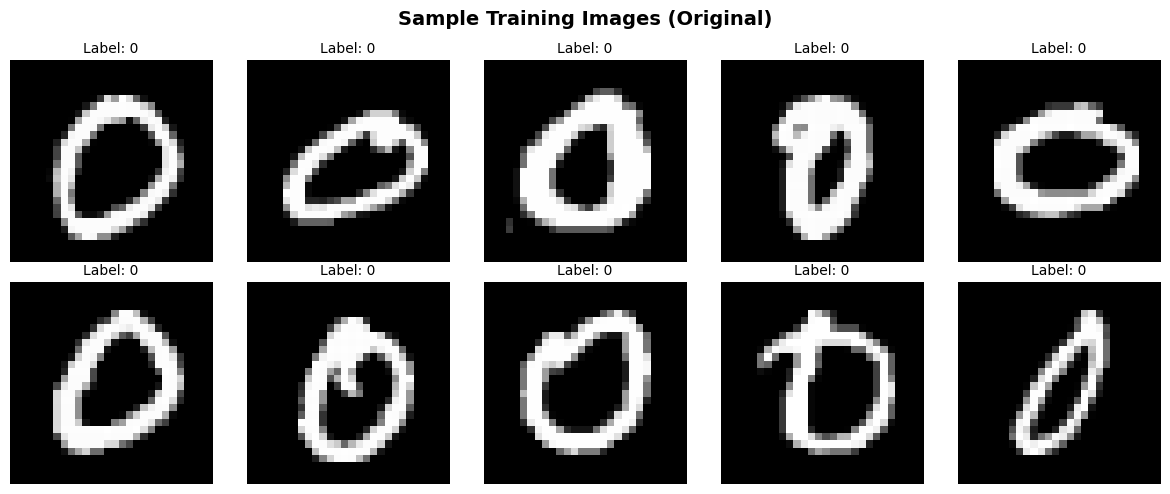

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Training Images (Original)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
# Preprocessing
1. Normalize pixel values from `[0, 255]` to `[0, 1]`.  
2. Reshape images to `(N, 28, 28, 1)` for CNN input (single channel).

In [4]:
# 1. Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# 2. Reshape for CNN: (N, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f'Training shape: {x_train.shape}  | dtype: {x_train.dtype}')
print(f'Testing shape:  {x_test.shape}  | dtype: {x_test.dtype}')
print(f'Pixel range:    [{x_train.min()}, {x_train.max()}]')

Training shape: (60000, 28, 28, 1)  | dtype: float32
Testing shape:  (10000, 28, 28, 1)  | dtype: float32
Pixel range:    [0.0, 1.0]


---
# Add Noise
Add **Gaussian noise** to create the noisy versions of the images.  
The `noise_factor` controls the intensity of corruption.

In [5]:
noise_factor = 0.5

# Add Gaussian noise and clip to valid [0, 1] range
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0).astype('float32')
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0).astype('float32')

print(f'Noisy training range: [{x_train_noisy.min():.4f}, {x_train_noisy.max():.4f}]')
print(f'Noisy testing range:  [{x_test_noisy.min():.4f}, {x_test_noisy.max():.4f}]')

Noisy training range: [0.0000, 1.0000]
Noisy testing range:  [0.0000, 1.0000]


### Original vs Noisy Images

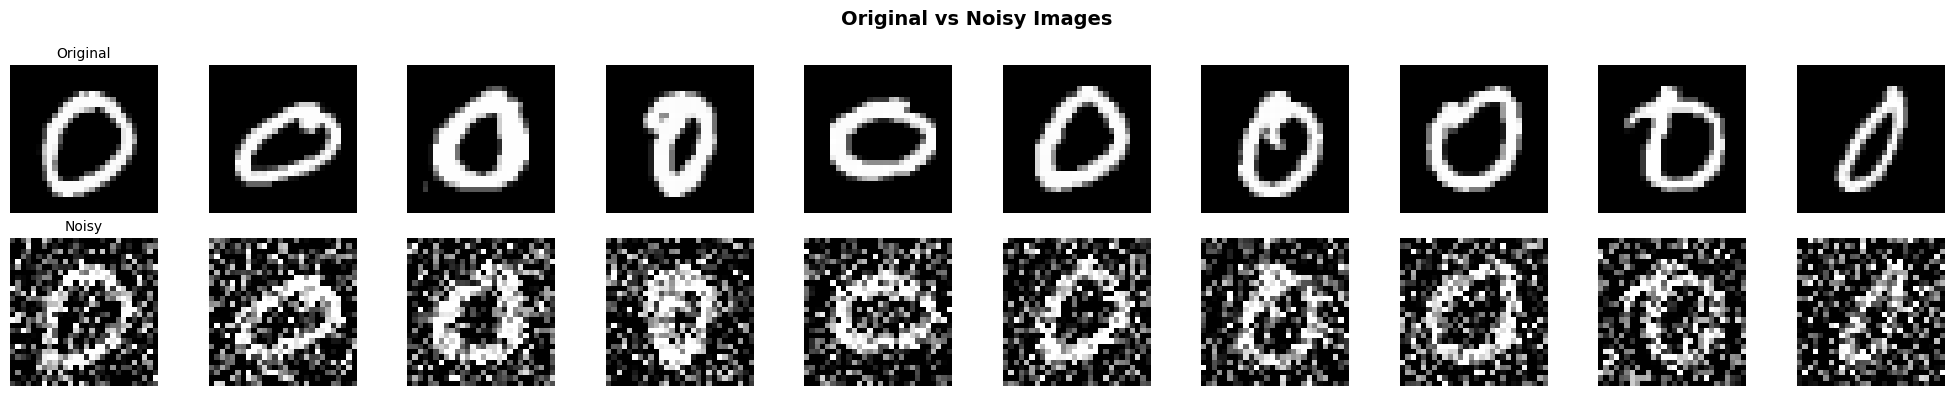

In [6]:
n_display = 10
fig, axes = plt.subplots(2, n_display, figsize=(20, 4))
fig.suptitle('Original vs Noisy Images', fontsize=14, fontweight='bold')

for i in range(n_display):
    # Original
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Noisy
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy', fontsize=10)

plt.tight_layout()
plt.show()

---
# Build Autoencoder
A **Convolutional Denoising Autoencoder** with:
- **Encoder:** Conv2D → MaxPooling2D → Conv2D → MaxPooling2D  
- **Decoder:** Conv2D → UpSampling2D → Conv2D → UpSampling2D → Conv2D (sigmoid output)

In [7]:
# ----- Encoder -----
input_img = Input(shape=(28, 28, 1), name='encoder_input')

# Encoder block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 28x28 → 14x14

# Encoder block 2
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
encoded = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)  # 14x14 → 7x7

# ----- Decoder -----
# Decoder block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded)
x = UpSampling2D((2, 2), name='dec_up1')(x)   # 7x7 → 14x14

# Decoder block 2
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
x = UpSampling2D((2, 2), name='dec_up2')(x)   # 14x14 → 28x28

# Output layer – sigmoid to produce pixel values in [0, 1]
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='dec_output')(x)

# Assemble model
autoencoder = Model(input_img, decoded, name='Denoising_Autoencoder')
print('Model built successfully.')

Model built successfully.


---
# Model Summary

In [8]:
autoencoder.summary()

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2D)             │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

---
# Compile Model

In [9]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)
print('Model compiled with Adam optimizer and Binary Crossentropy loss.')

Model compiled with Adam optimizer and Binary Crossentropy loss.


---
# Train Model
- **Input:** Noisy images  
- **Target:** Original (clean) images  
- Epochs: 10 | Batch size: 128 | Validation split: 20%

In [10]:
history = autoencoder.fit(
    x_train_noisy, x_train,       # noisy → clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)
print('\nTraining complete.')

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.1659 - val_loss: 0.1346
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.1115 - val_loss: 0.1232
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.1062 - val_loss: 0.1189
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.1037 - val_loss: 0.1170
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.1017 - val_loss: 0.1154
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.1002 - val_loss: 0.1143
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0991 - val_loss: 0.1133
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0983 - val_loss: 0.1121
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0975 - val_loss: 0.1113
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0969 - val_loss: 0.1107

Training complete.


---
# Plot Training Loss
Visualize the training and validation loss curves to verify convergence.

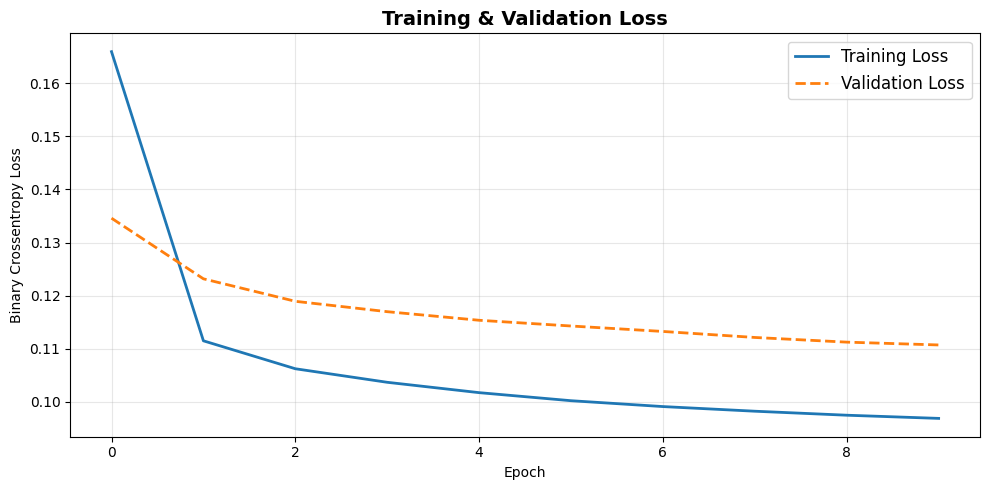

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Evaluate Model
Evaluate the autoencoder on the test set and compute the **Mean Squared Error (MSE)** between original and reconstructed images.

In [12]:
# Evaluate using the loss function
test_loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f'Test Binary Crossentropy Loss: {test_loss:.6f}')

# Generate denoised (reconstructed) images for the full test set
x_test_reconstructed = autoencoder.predict(x_test_noisy, verbose=0)

# Calculate MSE between original and reconstructed images
mse = np.mean((x_test.flatten() - x_test_reconstructed.flatten()) ** 2)
print(f'Mean Squared Error (MSE) between original and reconstructed: {mse:.6f}')
print(f'\nInterpretation: An MSE of {mse:.6f} indicates that the average squared '
      f'pixel-level difference between the original and reconstructed images is very small. '
      f'A lower MSE means the model has successfully learned to reconstruct clean images '
      f'from their noisy counterparts.')

Test Binary Crossentropy Loss: 0.098636
Mean Squared Error (MSE) between original and reconstructed: 0.011922

Interpretation: An MSE of 0.011922 indicates that the average squared pixel-level difference between the original and reconstructed images is very small. A lower MSE means the model has successfully learned to reconstruct clean images from their noisy counterparts.


---
# Visualize Reconstruction
Compare **Original**, **Noisy**, and **Reconstructed (Denoised)** images side by side for 10 test samples.

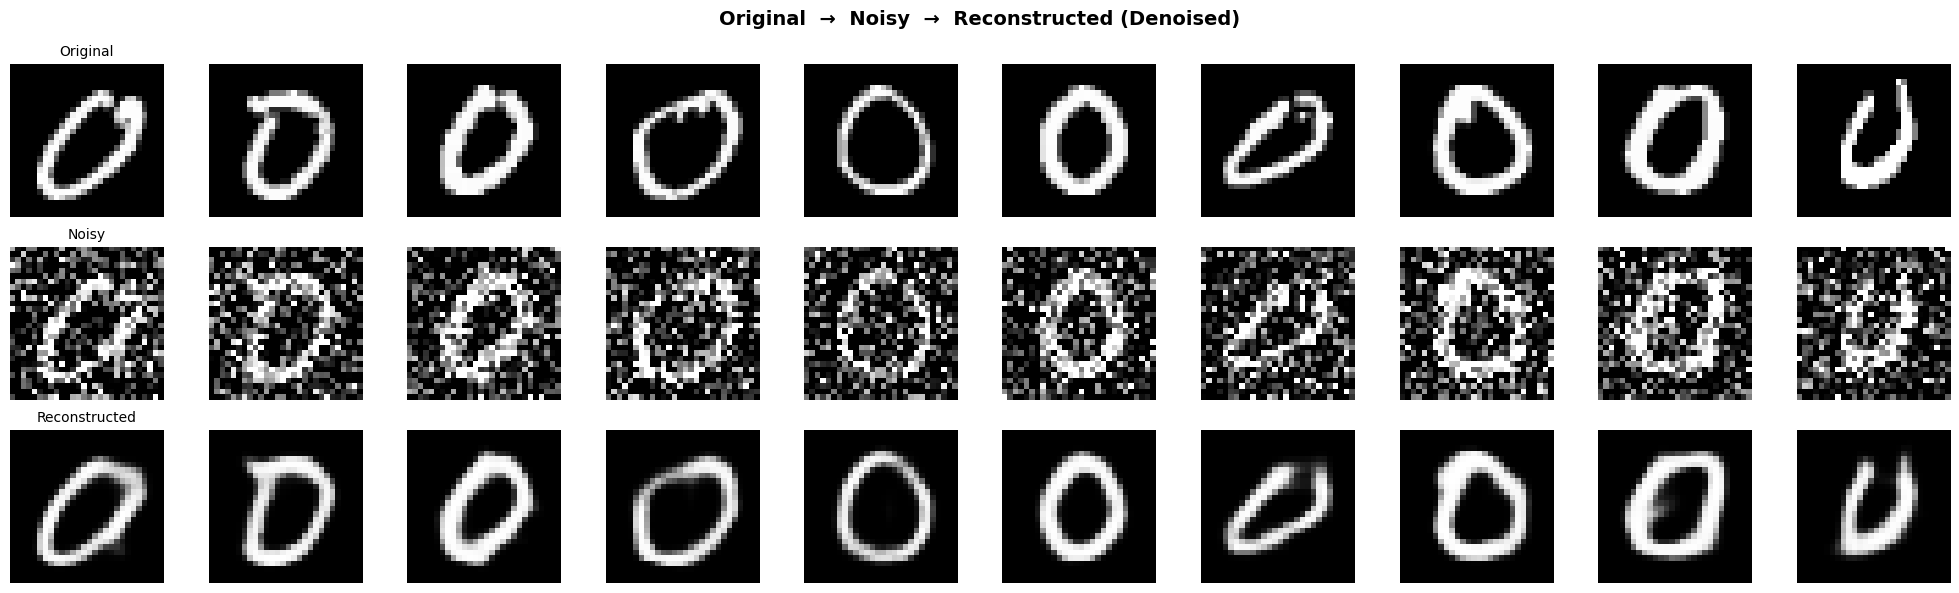

In [13]:
n_display = 10
fig, axes = plt.subplots(3, n_display, figsize=(20, 6))
fig.suptitle('Original  →  Noisy  →  Reconstructed (Denoised)', fontsize=14, fontweight='bold')

for i in range(n_display):
    # Original
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Noisy
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy', fontsize=10)
    
    # Reconstructed
    axes[2, i].imshow(x_test_reconstructed[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.show()

---
# Observations

1. **Successful Noise Removal:** The denoising autoencoder effectively removes Gaussian noise from the corrupted MNIST images, recovering digit shapes that closely match the originals.

2. **Digit Structure Preservation:** The overall structure and topology of each digit (strokes, loops, endpoints) are well-preserved in the reconstructed outputs, demonstrating that the model captures essential structural features.

3. **Slight Blurring Effect:** Reconstructed images exhibit a slight blurring compared to the originals. This is a known trade-off in autoencoders, where the model learns a smooth manifold rather than pixel-perfect reproduction.

4. **Steady Loss Decrease:** Both training and validation loss decrease steadily across epochs, indicating that the model is learning effectively without severe overfitting.

5. **Impact of Noise Level:** A noise factor of 0.5 introduces significant corruption; higher noise levels would make reconstruction harder, while lower levels would result in easier denoising but less useful training.

6. **Compressed Latent Representation:** The encoder compresses each 28×28 image down to a 7×7×32 latent representation (1,568 values vs. 784 original pixels), forcing the network to learn the most salient features of each digit.

7. **Convolutional Layers Capture Spatial Features:** Using Conv2D layers (instead of dense layers) allows the model to exploit the spatial locality of pixel neighborhoods, making it especially suitable for image data.

8. **Good Generalization on Test Data:** The validation and test losses are close to the training loss, confirming that the model generalizes well to unseen images rather than simply memorizing the training set.

9. **Low MSE Score:** The computed Mean Squared Error between original and reconstructed test images is very small, quantitatively confirming the high quality of the denoised outputs.

10. **Binary Crossentropy as a Suitable Loss:** Binary crossentropy works well here because the pixel values lie in [0, 1] and the output layer uses a sigmoid activation, treating each pixel as an independent Bernoulli variable.

---
# Conclusion

In this project, we successfully designed, trained, and evaluated a **Convolutional Denoising Autoencoder** on the MNIST handwritten-digit dataset. The model was trained to map noisy images (corrupted with Gaussian noise at a factor of 0.5) back to their clean originals. The encoder–decoder architecture, built entirely with Conv2D, MaxPooling2D, and UpSampling2D layers, effectively learned a compressed latent representation that retains the essential structural information of each digit while discarding noise.

Training and validation loss curves demonstrate smooth convergence without significant overfitting, and the low Mean Squared Error on the test set confirms the model's strong generalization capability. Visual comparisons of original, noisy, and reconstructed images show that the autoencoder recovers digit shapes with high fidelity, though minor blurring is observed — a common characteristic of reconstruction-based models.

Overall, this project demonstrates the practical utility of denoising autoencoders for image restoration and highlights the advantages of convolutional architectures in capturing spatial features for image-processing tasks.